In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model

In [36]:
# Set pandas display option to show floats without scientific notation
pd.options.display.float_format = '{:,.2f}'.format

After applying the new display format, let's look at the head of the DataFrame again to see the 'Price' column without scientific notation:

In [37]:
display(df.head())

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,"79,545.46",5.68,7.01,4.09,"23,086.80","1,059,033.56","208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,"79,248.64",6.00,6.73,3.09,"40,173.07","1,505,890.91","188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,"61,287.07",5.87,8.51,5.13,"36,882.16","1,058,987.99","9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,"63,345.24",7.19,5.59,3.26,"34,310.24","1,260,616.81",USS Barnett\nFPO AP 44820
4,"59,982.20",5.04,7.84,4.23,"26,354.11","630,943.49",USNS Raymond\nFPO AE 09386


In [38]:
df = pd.read_csv("USA_Housing.csv")
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,"79,545.46",5.68,7.01,4.09,"23,086.80","1,059,033.56","208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,"79,248.64",6.00,6.73,3.09,"40,173.07","1,505,890.91","188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,"61,287.07",5.87,8.51,5.13,"36,882.16","1,058,987.99","9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,"63,345.24",7.19,5.59,3.26,"34,310.24","1,260,616.81",USS Barnett\nFPO AP 44820
4,"59,982.20",5.04,7.84,4.23,"26,354.11","630,943.49",USNS Raymond\nFPO AE 09386


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


In [4]:
df.shape

(5000, 7)

In [39]:
df.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,"5,000.00","5,000.00","5,000.00","5,000.00","5,000.00","5,000.00"
mean,"68,583.11",5.98,6.99,3.98,"36,163.52","1,232,072.65"
std,"10,657.99",0.99,1.01,1.23,"9,925.65","353,117.63"
min,"17,796.63",2.64,3.24,2.00,172.61,"15,938.66"
25%,"61,480.56",5.32,6.30,3.14,"29,403.93","997,577.14"
50%,"68,804.29",5.97,7.00,4.05,"36,199.41","1,232,669.38"
75%,"75,783.34",6.65,7.67,4.49,"42,861.29","1,471,210.20"
max,"107,701.75",9.52,10.76,6.50,"69,621.71","2,469,065.59"


In [8]:
df.isnull().sum()

,0
Avg. Area Income,0
Avg. Area House Age,0
Avg. Area Number of Rooms,0
Avg. Area Number of Bedrooms,0
Area Population,0
Price,0
Address,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [40]:
X= df.drop(['Price','Address'],axis=1)
Y= df.Price

In [41]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [16]:
lr = linear_model.LinearRegression()
lr.fit(X_train,Y_train)

LinearRegression()

In [42]:
lr.score(X_test,Y_test)

0.9179971706834289

In [43]:
lr.coef_

array([2.16522058e+01, 1.64666481e+05, 1.19624012e+05, 2.44037761e+03,
       1.52703134e+01])

In [44]:
lr.intercept_

np.float64(-2635072.900933358)

In [22]:
y_pred= lr.predict(X_test)

In [46]:
test = {"actual": Y_test, "predicted": y_pred}
test_df = pd.DataFrame(test)
test_df


,actual,predicted
1501,"1,339,096.08","1,308,587.93"
2586,"1,251,794.18","1,237,037.23"
2653,"1,340,094.97","1,243,429.34"
1055,"1,431,507.62","1,228,900.21"
705,"1,042,373.52","1,063,320.91"
...,...,...
4711,"1,107,031.25","1,042,902.58"
2313,"1,405,505.24","1,318,531.80"
3214,"1,924,155.58","1,870,001.48"
2732,"1,571,253.53","1,663,623.86"


In [45]:
test_df['actual']==test_df['predicted']

,0
1501,False
2586,False
2653,False
1055,False
705,False
...,...
4711,False
2313,False
3214,False
2732,False


### Scatter Plots with Linear Fit

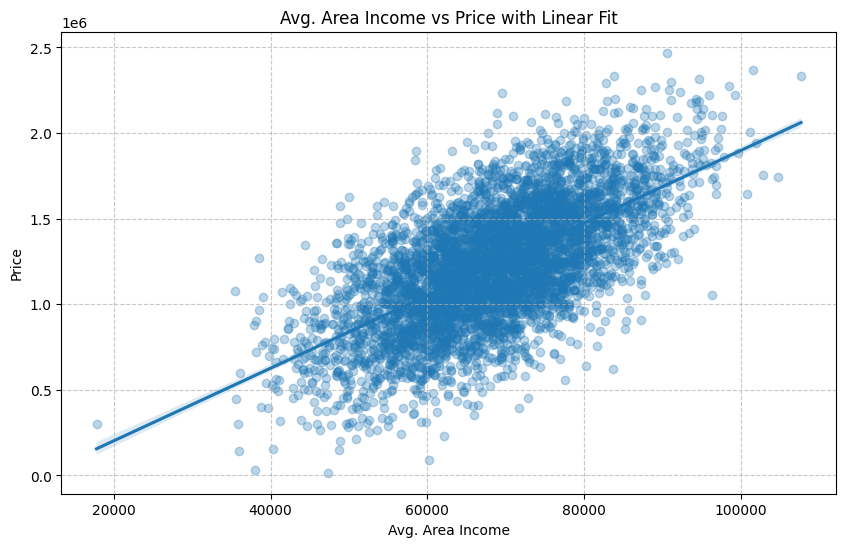

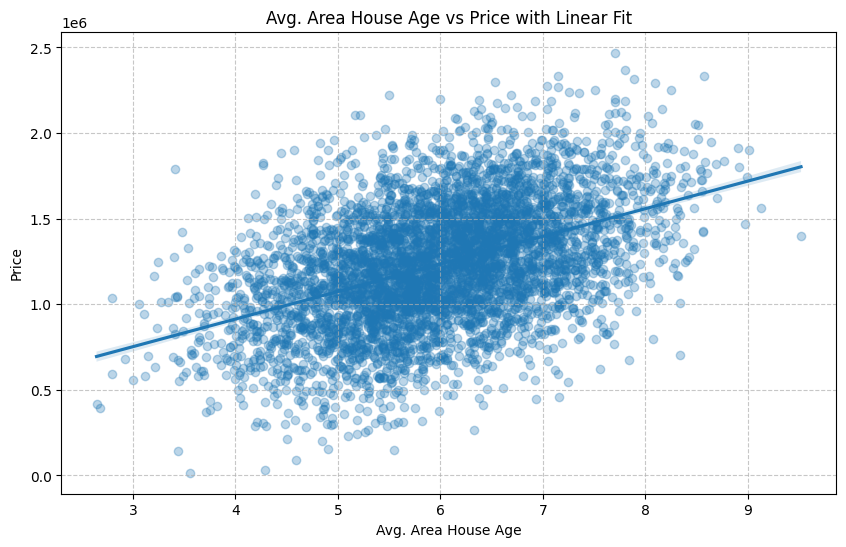

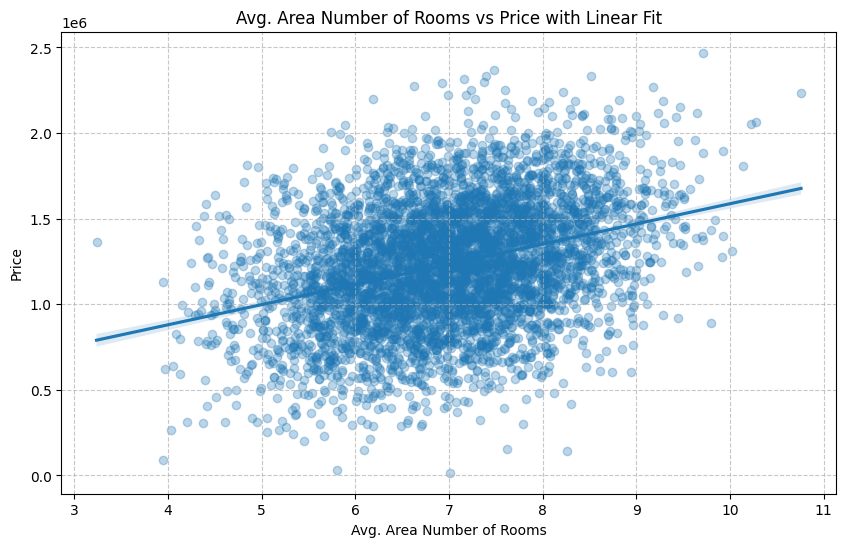

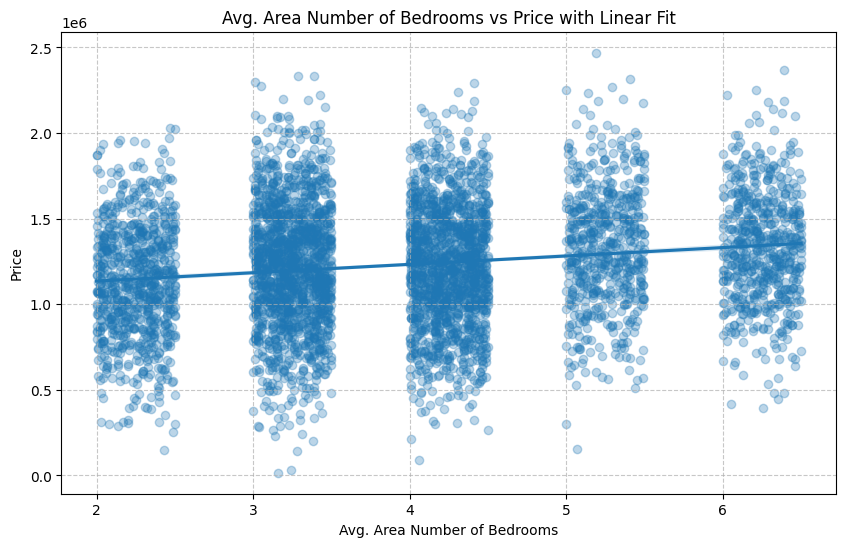

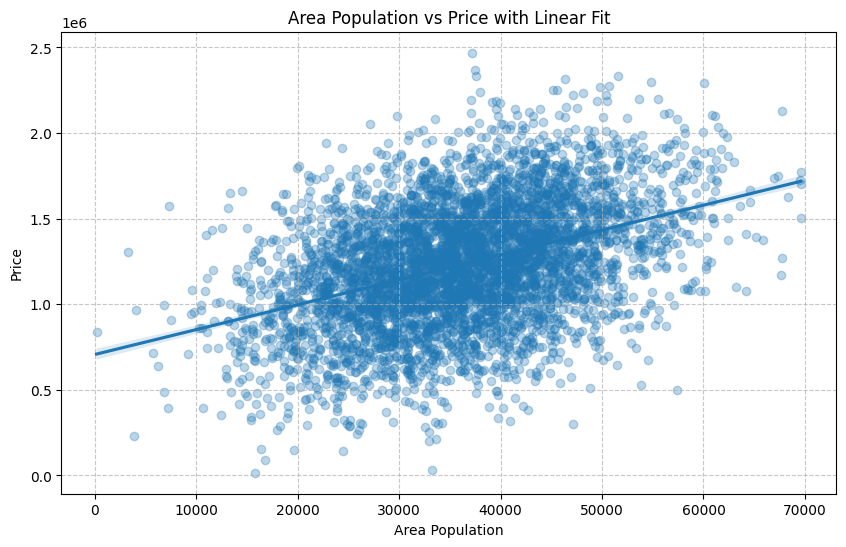

In [47]:
import seaborn as sns

# Create scatter plots with linear fit for each feature vs Price
for column in X.columns:
    plt.figure(figsize=(10, 6))
    sns.regplot(x=df[column], y=df['Price'], scatter_kws={'alpha':0.3})
    plt.title(f'{column} vs Price with Linear Fit')
    plt.xlabel(column)
    plt.ylabel('Price')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

### Correlation Matrix

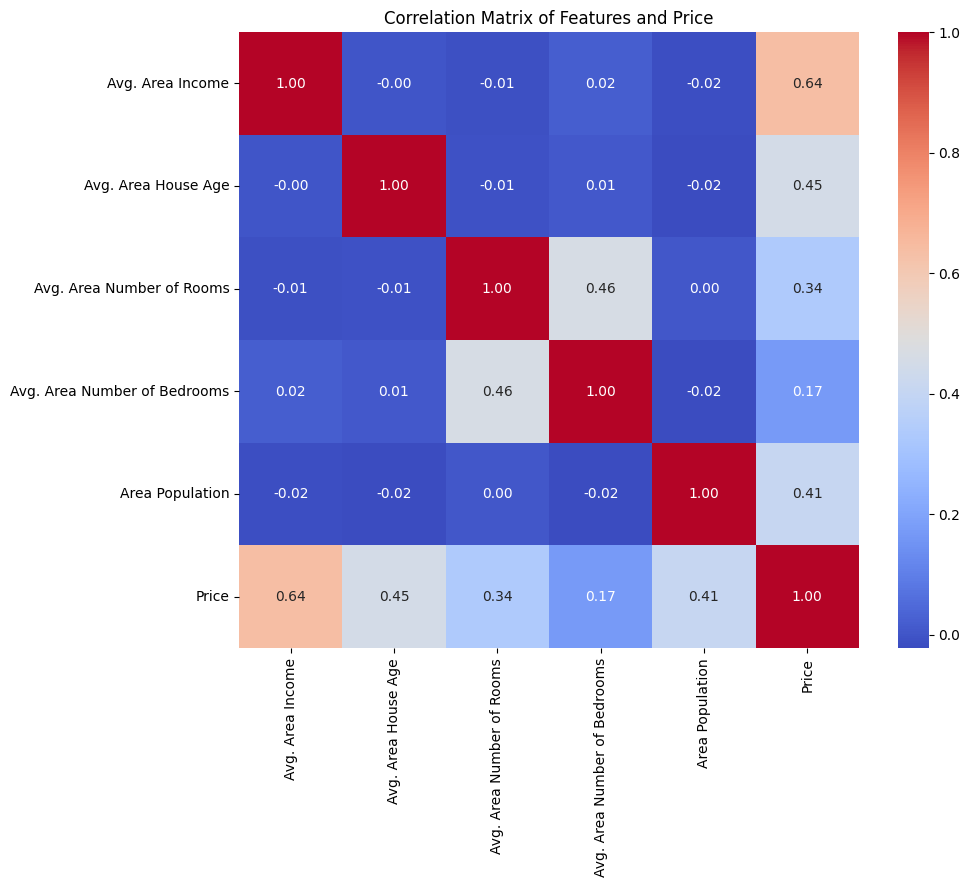

In [48]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features and Price')
plt.show()

### Model Performance: Y_pred vs Y_test and Regression Metrics

Now, let's make predictions using our trained linear regression model and compare them to the actual values from the test set. We'll also calculate additional regression metrics to assess the model's performance comprehensively.

First, a note on the **Confusion Matrix**: A confusion matrix is a table that is often used to describe the performance of a classification model (e.g., predicting 'yes' or 'no'). Since your task is to predict a continuous value ('Price'), which is a regression problem, a confusion matrix is not applicable here. Instead, we use metrics like Mean Absolute Error, Mean Squared Error, and R-squared.

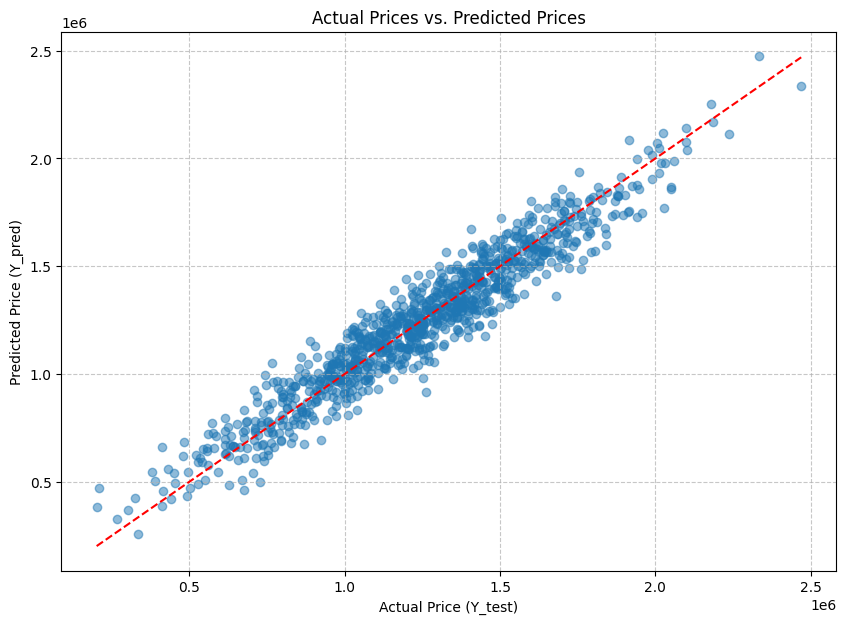

R-squared (from lr.score): 0.9179971706834289
Mean Absolute Error (MAE): 80879.0972348982
Mean Squared Error (MSE): 10089009300.894518
Root Mean Squared Error (RMSE): 100444.06055558745


In [49]:
from sklearn import metrics

Y_pred = lr.predict(X_test)

# Scatter plot of Actual vs Predicted Prices
plt.figure(figsize=(10, 7))
plt.scatter(Y_test, Y_pred, alpha=0.5)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--') # Plotting the ideal line
plt.xlabel('Actual Price (Y_test)')
plt.ylabel('Predicted Price (Y_pred)')
plt.title('Actual Prices vs. Predicted Prices')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Displaying the regression metrics
print('R-squared (from lr.score):', lr.score(X_test, Y_test))
print('Mean Absolute Error (MAE):', metrics.mean_absolute_error(Y_test, Y_pred))
print('Mean Squared Error (MSE):', metrics.mean_squared_error(Y_test, Y_pred))
print('Root Mean Squared Error (RMSE):', np.sqrt(metrics.mean_squared_error(Y_test, Y_pred)))

In [71]:
# Avg area income, Avg. Area House age,Avg. Number or rooms, Avg. Numers of Bedrooms, Area Population
lr.predict([[75000,15,6,4,25000]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([2568103.16175241])

In [79]:
# Avg area income, Avg. Area House age,Avg. Number or rooms, Avg. Numers of Bedrooms, Area Population
lr.predict([[35000,4.5,5.5,3,35000]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([63467.63420021])

#### Explanation of Terms:

*   **R-squared (Coefficient of Determination):** Measures how well the regression predictions approximate the real data points. An R-squared of 1 indicates that the model perfectly predicts the target variable. Our value of ~0.918 means about 91.8% of the variance in housing prices can be explained by our model's features.

*   **Mean Absolute Error (MAE):** This is the average of the absolute differences between predictions and actual observations. It gives an idea of the magnitude of errors without considering their direction. A lower MAE indicates a more accurate model.

*   **Mean Squared Error (MSE):** This is the average of the squared differences between predictions and actual observations. It penalizes larger errors more heavily than MAE. A lower MSE indicates a more accurate model.

*   **Root Mean Squared Error (RMSE):** This is the square root of the MSE. It's often preferred over MSE because it has the same units as the target variable (Price), making it more interpretable. A lower RMSE indicates a more accurate model.

In [76]:
df[df['Price']<=150000].sort_values(by='Price',ascending=False)

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
1459,"35,963.33",3.44,8.26,3.28,"24,435.78","143,027.36","166 Terry Grove\nSouth Michaelhaven, PR 18054"
1799,"60,167.67",4.59,3.95,4.06,"16,811.30","88,591.77","97009 Annette Vista\nMichaelside, AZ 39867"
1271,"37,971.21",4.29,5.81,3.24,"33,267.77","31,140.52","98398 Terrance Pines\nSouth Joshua, MT 00544-8919"
3212,"47,320.66",3.56,7.01,3.16,"15,776.62","15,938.66","91410 Megan Camp Suite 360\nLaurafort, OH 15735"


### Summary of Data Analysis

So far, we have completed the following steps in our data analysis:

1.  **Data Loading and Initial Inspection**: We loaded the `USA_Housing.csv` dataset into a pandas DataFrame. We then used `df.head()`, `df.info()`, `df.shape`, `df.describe()`, `df.isnull().sum()`, and `df.duplicated().sum()` to get a general understanding of the data, check for missing values, and identify data types.
2.  **Data Preprocessing**: We separated the features (`X`) from the target variable (`Y`, which is 'Price'). We also dropped the 'Address' column from our features as it's not a numerical input for our linear model. Finally, we split the data into training and testing sets (`X_train`, `X_test`, `Y_train`, `Y_test`) to evaluate our model's performance on unseen data.
3.  **Model Training**: We initialized and trained a `LinearRegression` model using the training data (`X_train` and `Y_train`).
4.  **Prediction and Evaluation**: We used the trained model to make predictions (`Y_pred`) on the test set (`X_test`) and then evaluated its performance using various regression metrics and visualizations, including scatter plots, a correlation matrix, and a comparison of actual vs. predicted prices.

### Understanding the Correlation Matrix

The **correlation matrix** is a table that shows the correlation coefficients between different variables. In our heatmap:

*   **Color Scale**: The `cmap='coolwarm'` colormap indicates positive correlations with warmer colors (reds) and negative correlations with cooler colors (blues). A value close to 1 (dark red) means a strong positive correlation, a value close to -1 (dark blue) means a strong negative correlation, and a value close to 0 (light color, near white) means a weak or no linear correlation.
*   **Diagonal**: The diagonal elements are all `1.00` because each variable is perfectly correlated with itself.
*   **Symmetry**: The matrix is symmetric; the correlation between A and B is the same as between B and A.

**What it tells us for your data:**

*   **Relationship with Price**: Observe the last row (or column) which represents 'Price'.
    *   `Avg. Area Income` (0.64), `Avg. Area House Age` (0.45), `Avg. Area Number of Rooms` (0.34), and `Area Population` (0.41) all show a **positive correlation** with 'Price'. This means as these features increase, the 'Price' of the house tends to increase. 'Avg. Area Income' has the strongest positive correlation with 'Price'.
    *   `Avg. Area Number of Bedrooms` (0.17) also has a positive but weaker correlation with 'Price'.
*   **Inter-feature Relationships**: You can also see correlations between the features themselves. For example, `Avg. Area Number of Rooms` and `Avg. Area Number of Bedrooms` have a positive correlation (0.46), which makes sense as more rooms often imply more bedrooms.

### Interpreting the Regression Scores and Why They Might Seem 'High'

You've provided the following metrics:

*   **R-squared (from lr.score):** `0.9179971706834289`
*   **Mean Absolute Error (MAE):** `80879.0972348982`
*   **Mean Squared Error (MSE):** `10089009300.894518`
*   **Root Mean Squared Error (RMSE):** `100444.06055558745`

Let's understand each and address your concern about MAE, MSE, and RMSE being 'too high'.

1.  **R-squared (Coefficient of Determination)**: This is a measure of how well your model explains the variance in the target variable. An R-squared of `0.918` (or 91.8%) is **excellent**. It means that approximately 91.8% of the variability in house prices can be explained by the features included in your model. This is a very strong indicator that your model fits the data well.

2.  **Mean Absolute Error (MAE)**: The MAE is about `$80,879.09`. This means, on average, your model's predictions are off by about \$80,879.09 from the actual house prices. The units of MAE are the same as the target variable (dollars).

3.  **Mean Squared Error (MSE)**: The MSE is `10,089,009,300.89`. This metric penalizes larger errors more severely. It's often harder to interpret directly because its units are the square of the target variable's units (dollars squared).

4.  **Root Mean Squared Error (RMSE)**: The RMSE is about `$100,444.06`. Like MAE, RMSE is expressed in the same units as the target variable (dollars), making it more interpretable than MSE. It represents the standard deviation of the residuals (prediction errors).

**Why MAE, MSE, and RMSE might seem 'high' but are actually reasonable:**

Your concern about these values being 'high' is valid if you look at them in isolation. However, their significance must be judged **relative to the scale of your target variable, 'Price'**.

From `df.describe()`, we know the 'Price' ranges from approximately \$15,938 to \$2,469,065, with a mean of approximately \$1,232,072.65. The standard deviation of the price is around \$353,117.63.

*   An **MAE of ~\$80,879** and an **RMSE of ~\$100,444** are about 6.5% and 8.1% of the average house price, respectively. Compared to a standard deviation of \$353,117.63, an RMSE of \$100,444 is actually quite good. It means your model's typical prediction error is significantly less than the natural variation in house prices.
*   If your average house price was, say, \$5,000, then an MAE of \$80,000 would indeed be extremely high. But for house prices often exceeding a million dollars, errors in this range, coupled with an **R-squared of 0.918**, indicate a **highly effective and well-performing model**.

In summary, while the absolute numbers for MAE and RMSE are large, they are small when considered relative to the scale of house prices in your dataset. The excellent R-squared value confirms that your model is doing a great job at predicting house prices.